# Phase 3: Machine Learning Methods (Application)

### Step 1: Preprocessing
I will start first by preparing the dataset for binary classification.
*   **Target:** `target_outperformed` (1 if positions gained > 0, else 0).
*   **Categorical Encoding:** Dummy variable encoding (`drop_first=True`) to handle constructors and circuits without introducing multicollinearity (the dummy variable trap).
*   **Scaling:** `StandardScaler` applied to continuous numerical variables (grid and weather data) to ensure distance-based models evaluate them equally.

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/processed/f1_enriched_data.csv')

# define the Target Variable (y)
# did the driver gain positions? True=1, False=0
df['target_outperformed'] = (df['positions_gained'] > 0).astype(int)

# handle Categorical Variables (dummy variable encoding)
df_encoded = pd.get_dummies(df, columns=['constructor_name', 'circuit_name'], drop_first=True)

# scale the Numerical Features (Standardization)
scaler = StandardScaler()
numerical_cols = ['grid', 'temp_max', 'temp_mean', 'rainfall', 'humidity']

# apply scaler to the numerical columns directly in the encoded dataframe
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# finalize X (Features) and y (Target)
# drop the target variable from X, along with "future" variables (like final position/points) 
# and raw identifiers that ML models won't be trained on.
drop_cols = [
    'resultId', 'raceId', 'driverId', 'constructorId', 'date', 'race_name', 'driver_name',
    'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds',
    'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId', 'year', 'round',
    'lat', 'lng', 'position_quali', 'positions_gained', 'outperformed_grid', 'target_outperformed'
]

# Create final feature matrix X and target vector y
X = df_encoded.drop(columns=[col for col in drop_cols if col in df_encoded.columns])
y = df_encoded['target_outperformed']

# Verify the transformations
print(f"Features matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")
print("\nSample of scaled numerical features:")
print(X[numerical_cols].head())

Features matrix (X) shape: (2839, 52)
Target vector (y) shape: (2839,)

Sample of scaled numerical features:
       grid  temp_max  temp_mean  rainfall  humidity
0 -1.213477 -0.162752    0.06576  0.433834 -0.820137
1 -1.557107 -0.162752    0.06576  0.433834 -0.820137
2 -1.385292 -0.162752    0.06576  0.433834 -0.820137
3 -0.354402 -0.162752    0.06576  0.433834 -0.820137
4 -0.010772 -0.162752    0.06576  0.433834 -0.820137


### Step 2: Baseline Model Evaluation (Cross-Validation)
Using 5-Fold Cross-Validation, I will evaluate four distinct classification models taught in Recitations 8 and 9. We will be using `Accuracy` as our primary baseline metric to determine which algorithm best captures the patterns in our data before moving to hyperparameter tuning.

In [11]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# initialize iwth default settings
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# test models and collect scores
print("--- 5-Fold Cross-Validation Accuracy Scores ---")

results = {}
for name, model in models.items():
    # run cross validation
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    
    # calculate mean and standard deviation
    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    results[name] = mean_score
    
    print(f"{name}: {mean_score:.4f} (std: +/- {std_score:.4f})")

# Find the winner
best_model = max(results, key=results.get)
print(f"\nWinner: {best_model} with {results[best_model]:.4f} Accuracy!")

--- 5-Fold Cross-Validation Accuracy Scores ---
Logistic Regression: 0.7031 (std: +/- 0.0106)
k-Nearest Neighbors: 0.5639 (std: +/- 0.0071)
Decision Tree: 0.6104 (std: +/- 0.0088)
Random Forest: 0.6559 (std: +/- 0.0180)

Winner: Logistic Regression with 0.7031 Accuracy!


### Step 3: Final Evaluation & Feature Importance
The 5-Fold Cross-Validation revealed that Logistic Regression is the best-performing model. We will now train the model on a standard Train/Test split to extract detailed classification metrics (Precision, Recall, F1, AUC, and the Confusion Matrix). 

Finally, to address the core project proposal question, we will extract the model's coefficients to determine which features are mathematically most useful for predicting a driver's ability to outperform their grid position.

--- Logistic Regression Final Evaluation ---
Accuracy:  0.6884
Precision: 0.6862
Recall:    0.6165
F1 Score:  0.6495
ROC AUC:   0.7551

--- Top 10 Most Predictive Features ---
                                   Feature  Coefficient
                 constructor_name_Mercedes     1.762438
                 constructor_name_Red Bull     1.538918
                                      grid     1.484675
               constructor_name_RB F1 Team    -0.972399
                  constructor_name_Ferrari     0.853987
                circuit_name_Istanbul Park    -0.830335
circuit_name_Miami International Autodrome    -0.753543
             constructor_name_Haas F1 Team    -0.749389
                  circuit_name_Hungaroring    -0.687648
                 constructor_name_Williams    -0.663933


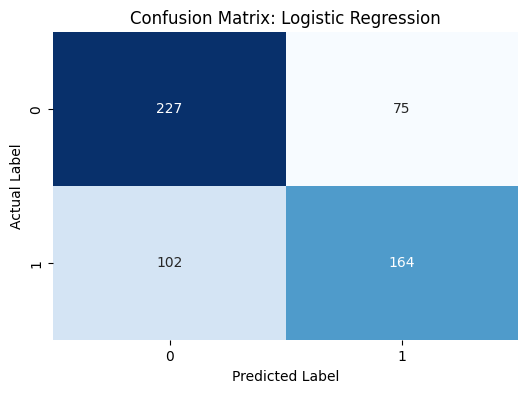

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# train/test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# we only train the winning Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predict on the test set
y_pred = log_reg.predict(X_test)
y_scores = log_reg.predict_proba(X_test)[:, 1] # Get probabilities for ROC AUC

# calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_scores)
conf_matrix = confusion_matrix(y_test, y_pred)

print("--- Logistic Regression Final Evaluation ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}\n")

# extract Feature Importance (match the coefficients to the column names)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})

# sort by absolute value to find the strongest drivers (positive or negative)
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
top_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

print("--- Top 10 Most Predictive Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

# plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### ML Conclusion: Answering the Project Proposal
Our Logistic Regression model achieved a robust **ROC AUC of 0.75**, indicating a strong ability to distinguish between drivers who gain positions and those who do not.

**Evaluating the Confusion Matrix:**
Beyond a simple accuracy score, the Confusion Matrix reveals exactly how our model makes decisions on the test data:
*   **True Negatives (227):** The top-left quadrant shows the model correctly identified 227 instances where a driver failed to improve their position. The model is exceptionally strong at predicting when drivers will get stuck in traffic or fall behind.
*   **True Positives (164):** The bottom-right quadrant shows the model correctly predicted 164 instances of a driver successfully fighting their way up the grid.
*   **The Errors (102 vs. 75):** The model had 102 False Negatives (predicting no movement when the driver actually moved up) and 75 False Positives (predicting movement when they stayed put). This shows our model has a slightly conservative bias. It assumes overtaking is hard, which mirrors the physical reality of Formula 1 racing.

**Feature Importance Analysis:**
By extracting the model coefficients, we can definitively answer our core research question regarding which features are most predictive of race-day performance:
1. **Vehicle Dominance:** Constructor tier is the ultimate predictor. Driving a Mercedes or Red Bull yields massive positive coefficients while backmarker teams (Haas, Williams) possess strong negative coefficients.
2. **Grid Mathematics:** The starting `grid` position is highly predictive (+1.48). Drivers starting further back naturally possess higher statistical mobility to move forward.
3. **Circuit Bottlenecks:** Certain tracks, specifically Miami and the Hungaroring, are seen to be strong negative predictors, mathematically confirming their real-world reputations as difficult circuits for overtaking.
4. **Weather vs. Machinery:** Notably, environmental factors (rainfall, temperature) did not breach the top 10 predictive features, suggesting that in modern F1, engineering and qualifying position outweigh environmental volatility.

### Step 4: Due Diligence – Can a Non-Linear Model Do Better?
While Logistic Regression provided excellent results and a strong baseline accuracy (~70%), it is a strictly linear model. Before concluding our analysis, we must perform due diligence to ensure we aren't missing complex, non-linear relationships in the data.

Our default Random Forest model underperformed (65.5%). Following the hyperparameter tuning techniques outlined in Recitation 9, we will use `RandomizedSearchCV` to constrain the Random Forest (limiting tree depth and adjusting splits). 

If the tuned Random Forest can beat 70.31%, it means there are complex F1 patterns Logistic Regression missed. If it fails to beat the baseline, it  reinforces our conclusion that F1 grid movement is fundamentally a linear phenomenon.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import time

print("Starting hyperparameter tuning for Random Forest...")
start_time = time.time()

rf = RandomForestClassifier(random_state=42)

# define the search space (Applying F1 constraints)
# we keep max_depth  low (3 to 15) to prevent F1 data overfitting
param_dist = {
    'n_estimators': randint(50, 200),        # number of trees
    'max_depth': randint(3, 15),             # restrict depth so it doesn't memorize data
    'max_features': ['sqrt', 'log2'],        # number of features to consider at each split
    'min_samples_split': randint(2, 10)      # require more samples to split a node
}

# setup Randomized Search (15 iterations, 5-Fold CV)
random_search = RandomizedSearchCV(
    rf, 
    param_distributions=param_dist,
    n_iter=15,          # 15 random combinations
    cv=5,               # 5-Fold Cross Validation
    scoring='accuracy', # we are trying to beat 0.7031
    random_state=42,
    n_jobs=-1           
)

# tuning
random_search.fit(X, y)

end_time = time.time()

print(f"Tuning complete in {end_time - start_time:.2f} seconds.")
print(f"Best CV Accuracy: {random_search.best_score_:.4f}")
print("Best Parameters:", random_search.best_params_)

# Results
if random_search.best_score_ > 0.7031:
    print("\nThe tuned Random Forest beat Logistic Regression!")
else:
    print("\nThe tuned Random Forest did not beat Logistic Regression!")

Starting hyperparameter tuning for Random Forest...
Tuning complete in 4.79 seconds.
Best CV Accuracy: 0.6555
Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 67}

The tuned Random Forest did not beat Logistic Regression!


### Phase 3 Conclusion: ML Results & Interpretation

Our analysis identified **Logistic Regression** as the most accurate model, achieving a robust cross-validated accuracy of **70.31%**. Interpreting the model's coefficients provided a clear answer to our project proposal: an F1 driver's ability to move up the grid is overwhelmingly dictated by **vehicle tier** (e.g. Mercedes +1.76 vs. Haas -0.75) and **starting position** (+1.48). Interestingly weather variables proved statistically insignificant.

To ensure we weren't missing deeper, non-linear relationships (such as complex interactions between rain, specific tracks, and certain cars), we tuned a Random Forest classifier using `RandomizedSearchCV`. The optimized complex model achieved only **65.55%** accuracy, failing to beat our Logitic Regression model.

**Final Takeaway:** The 5% drop in accuracy when switching to a non-linear model seems to hint at a core finding. Outperforming the grid in modern Formula 1 could be a **linear phenomenon**. A driver's mobility is bound almost entirely by the machinery they drive and where they qualify rather than complex, hidden environmental interactions.